# CompliancePatchBench - Colab GRPO Training

> **AI systems can pass tests and still be wrong.**
> This benchmark trains agents that must fix code correctly, even when tests are misleading.

**Key idea:** the model generates JSON patch actions, `CompliancePatchEnv` executes them, and TRL `GRPOTrainer` updates the same policy from real environment reward.

**Framing (be honest with judges):** this is **lightweight online RL** optimized for *real* environment feedback, not a huge offline RL research stack. The goal is behavior that generalizes, not a fancy algorithm name.

**Noisy reward curves are normal in RL.** Watcher tip: use the **running average** plot below, not a single wobbly line, to read the *trend*.

This notebook is designed for **Google Colab GPU** training.

1. Install Unsloth, TRL, Transformers, Datasets, Pydantic, and Matplotlib.
2. Clone the project repo into `/content/CompliancePatchBench`.
3. Verify the environment reward and anti-cheat penalty.
4. Generate tasks and run a baseline.
5. Train `unsloth/Qwen2.5-3B-Instruct` with TRL `GRPOTrainer` on Colab GPU.
6. Log reward, success, hidden violations, output length, and termination health.
7. Save the adapter and reports under `/content`.

Stable RL settings: `max_new_tokens=150` (EOS + `}` stop), `learning_rate=2e-5`, `temperature=0.3` for training, `temperature=0.0` for evaluation, `max_steps=8`, `max_tasks=20`, GRPO trainer `max_steps≈45` (env RL loop default `iterations=45`).

## 1 — Install Colab training dependencies
Use a Colab GPU runtime. Unsloth keeps the 3B GRPO run small enough for a bounded demo.

In [1]:
!pip install -q accelerate bitsandbytes
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q trl transformers datasets pydantic matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 23.6 MB/s eta 0:00:00


In [2]:
import torch

print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise RuntimeError('Enable a Colab GPU runtime before running GRPO training.')

CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2 — Clone the repo & import the project package

**IMPORTANT:** Set `REPO_URL` below to the repository you are submitting or demoing.

Default placeholder: `https://github.com/YOUR_USERNAME/CompliancePatchBench.git`

In [3]:
import os, sys, subprocess

REPO_URL = 'https://github.com/skypank-coder/CompliancePatchBench.git'
REPO_DIR = '/content/CompliancePatchBench'

if not os.path.exists(REPO_DIR):
    print(f'Cloning {REPO_URL}...')
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
    print('Clone complete')
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=False)
    print(f'Repo updated at {REPO_DIR}')

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f'Working dir: {os.getcwd()}')
print(f'environment/ exists: {os.path.exists("environment")}')
print(f'environment/patch_env.py: {os.path.exists("environment/patch_env.py")}')


Cloning https://github.com/skypank-coder/CompliancePatchBench.git...
Clone complete
Working dir: /content/CompliancePatchBench
environment/ exists: True
environment/patch_env.py: True


## 2.5 — Verify Repository Setup
Quick check to ensure the project module is importable.

In [4]:
import os, sys

REPO_DIR = '/content/CompliancePatchBench'
if os.getcwd() != REPO_DIR:
    os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('=== Repository Verification ===')
checks = [
    'environment',
    'environment/patch_env.py',
    'environment/tasks/task1_single_file.py',
    'environment/tasks/task2_django_app.py',
    'environment/tasks/task3_microservices.py',
    'api/server.py',
]
all_good = True
for path in checks:
    exists = os.path.exists(path)
    print(f'{"OK" if exists else "MISSING"}: {path}')
    if not exists:
        all_good = False

from environment.patch_env import CompliancePatchEnv, compute_patch_reward
from environment.tasks.task1_single_file import get_task as get_task1
from environment.tasks.task2_django_app import get_task as get_task2

t1, t2 = get_task1(), get_task2()
print(f'Task1: {len(t1["ground_truth"])} violations')
print(f'Task2: {len(t2["ground_truth"])} violations')
print('All checks passed' if all_good else 'MISSING FILES - check clone step')


=== Repository Verification ===
OK: environment
OK: environment/patch_env.py
OK: environment/tasks/task1_single_file.py
OK: environment/tasks/task2_django_app.py
OK: environment/tasks/task3_microservices.py
OK: api/server.py
Task1: 3 violations
Task2: 8 violations
All checks passed


In [5]:
from environment.patch_env import CompliancePatchEnv, compute_patch_reward

# Verify the real environment reward before training.
r_deletion, _ = compute_patch_reward(
    state=None,
    ci_passed=True,
    tests_passed=True,
    lines_changed=1,
    patch_is_deletion=True,
    ast_node_delta=2,
)
assert r_deletion == -1.0, f'Deletion cheat should score -1.0, got {r_deletion}'

r_good, _ = compute_patch_reward(
    state=None,
    ci_passed=True,
    tests_passed=True,
    lines_changed=1,
    patch_is_deletion=False,
    ast_node_delta=2,
)
assert r_good > 1.0, f'Valid patch reward should be > 1.0, got {r_good}'

print('Environment verified')

Environment verified


## 3 — Generate the task fleet (40 mutated tasks)
The `task_generator` cycles through 12 hand-written templates and applies
mutations (rename files, shift severity, pad lines, sprinkle red-herrings)
to produce diverse variants from a small seed base.

In [6]:
import os, sys, importlib, json

REPO_DIR = '/content/CompliancePatchBench'
if os.getcwd() != REPO_DIR:
    os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Load task1–task5 and optional extra templates (diverse pool for GRPO + dataset)
_TASK_MODULES = [
    'task1_single_file',
    'task2_django_app',
    'task3_microservices',
    'task4_django_rest',
    'task5_fastapi',
    'task1b_connected',
    'task2b_multifile',
]
raw_tasks = []
_loaded_modules = []
for mod_name in _TASK_MODULES:
    try:
        m = importlib.import_module(f'environment.tasks.{mod_name}')
        raw_tasks.append(m.get_task())
        _loaded_modules.append(mod_name)
    except Exception as e:
        print(f'FAILED to load task: {mod_name}')
        print(f'  {type(e).__name__}: {e}')


def normalise_task(t):
    return {
        'task_id': t.get('task_id', 'unknown'),
        'codebase': t.get('codebase', {}),
        'violations': t.get('ground_truth', t.get('violations', [])),
        'framework': t.get('framework', ['GDPR']),
        'difficulty': t.get('difficulty', 'medium'),
        'file_reads_remaining': t.get('file_reads_remaining', 5),
        'adversarial': False,
    }

tasks = [normalise_task(t) for t in raw_tasks]

print()
print('=' * 60)
print('TASK LOAD SUMMARY (CompliancePatchBench)')
print('=' * 60)
_n_ok, _n_exp = len(tasks), len(_TASK_MODULES)
print(f'Total tasks successfully loaded: {_n_ok} (expected modules: {_n_exp})')
if _n_ok < _n_exp:
    print(f'  >>> {_n_exp - _n_ok} module(s) failed to import; check FAILED lines above.')
print()
print('Module → task_id:')
for mod, t in zip(_loaded_modules, tasks):
    print(f'  * {mod:22} →  {t["task_id"]}')
print()
print('Multi-file tasks in pool (2+ source files in codebase):')
_mf = [t for t in tasks if len(t.get('codebase', {})) > 1]
if _mf:
    for t in _mf:
        _keys = list(t['codebase'].keys())
        print(f'  * {t["task_id"]}  ({len(_keys)} files)')
else:
    print('  (none — possible import failure: no tasks or only single-file codebases loaded)')
print('=' * 60)
print('Per-task detail:')
for t in tasks:
    vcount = len(t['violations'])
    files = list(t['codebase'].keys())
    print(f'  {t["task_id"]}: {vcount} violations, {len(files)} file(s) — {files[:5]}{" ..." if len(files) > 5 else ""}')



TASK LOAD SUMMARY (CompliancePatchBench)
Total tasks successfully loaded: 7 (expected modules: 7)

Module → task_id:
  * task1_single_file      →  task1_single_file
  * task2_django_app       →  task2_django_app
  * task3_microservices    →  task3_microservices
  * task4_django_rest      →  task4_django_rest
  * task5_fastapi          →  task5_fastapi
  * task1b_connected       →  task1b_connected_violations
  * task2b_multifile       →  task2b_multifile_dependency

Multi-file tasks in pool (2+ source files in codebase):
  * task2_django_app  (5 files)
  * task3_microservices  (15 files)
  * task2b_multifile_dependency  (2 files)
Per-task detail:
  task1_single_file: 3 violations, 1 file(s) — ['routes.py']
  task2_django_app: 8 violations, 5 file(s) — ['models.py', 'views.py', 'serializers.py', 'middleware.py', 'settings.py']
  task3_microservices: 15 violations, 15 file(s) — ['auth_service/auth_models.py', 'auth_service/auth_views.py', 'auth_service/auth_middleware.py', 'user_service

## 4 — Roll out the heuristic agent → SFT dataset
We use the deterministic heuristic backend so the dataset is reproducible and free.
(Swap to `make_openai_backend` to bootstrap with GPT-4 traces if you want.)

In [7]:
# Build GRPO dataset directly from real tasks — no project module needed
import json
from collections import Counter

# CRITICAL: Keep this short. The prompt + violations must fit in max_prompt_length.
# Long system prompts get truncated by TRL and the model never sees the rules.
SYSTEM_PROMPT = """Output ONLY one JSON action. No prose. No markdown.
Actions: {"action_type":"read_file","path":"F"} | {"action_type":"write_patch","file":"F","line_start":N,"line_end":N,"new_code":"CODE"} | {"action_type":"run_ci"} | {"action_type":"finalize_patch"}
Never set new_code to empty string (-1.0 penalty). Fix violations minimally."""

# Many prompt lines × many tasks → 30+ dataset rows (better GRPO group advantages).
PROMPT_CLOSING_LINES = [
    "Output your first action now. JSON only.",
    "Return exactly one JSON object. No other text.",
    "Begin: emit a single minified JSON action next.",
    "Next line must be one JSON object only.",
    "Start with the character { and end with }.",
    "If unsure, use read_file first, then one JSON line.",
    "No markdown fences. One JSON only.",
    "Output the next step as one JSON value.",
]

# If a task has many violations, keep prompt under the tokenizer budget (see GRPO cell length check).
_SEVERITY_RANK = {"critical": 0, "high": 1, "medium": 2, "low": 3}
MAX_VIOLATIONS_IN_PROMPT = 12


def build_prompt(task: dict, closing: str) -> str:
    files = list(task['codebase'].keys())
    vlist = list(task.get('violations', []))
    vlist.sort(
        key=lambda v: _SEVERITY_RANK.get(str(v.get('severity', 'medium')).lower(), 2),
    )
    vlist = vlist[:MAX_VIOLATIONS_IN_PROMPT]
    violations = [
        {
            'rule_id': v['rule_id'],
            'file': v['file'],
            'line_start': v['line_start'],
            'line_end': v['line_end'],
            'severity': v['severity'],
        }
        for v in vlist
    ]
    user_msg = (
        f"Task ID: {task['task_id']}\n"
        f"Files available: {files}\n"
        f"Violations to fix:\n{json.dumps(violations, indent=2)}\n\n"
        f"{closing}"
    )
    return SYSTEM_PROMPT + "\n\n---\n\n" + user_msg


dataset_rows = []
for task in tasks:
    for closing in PROMPT_CLOSING_LINES:
        dataset_rows.append({
            'prompt': build_prompt(task, closing),
            'task_payload': json.dumps(task),
            'task_id': task['task_id'],
        })

# --- Auditability: dataset size, diversity, single-task failure mode ----------------
_row_ids = [r['task_id'] for r in dataset_rows]
_dist = Counter(_row_ids)
_n_rows = len(dataset_rows)
_n_unique = len(_dist)
print()
print('=' * 60)
print('DATASET SUMMARY (for GRPO)')
print('=' * 60)
print(f'  total_rows:  {_n_rows}  (prompt closings × tasks; {len(PROMPT_CLOSING_LINES)} variants per task)')
print(f'  unique_tasks:  {_n_unique}')
print('  rows_per_task:')
for _tid in sorted(_dist.keys()):
    print(f'    {_tid}:  {_dist[_tid]}')
if _n_unique == 1:
    print()
    print('WARNING: Only one task detected — training is not multi-task (prompt variants only).')
print()
print('Multi-file tasks in training pool (2+ source files in codebase):')
_mf = [t['task_id'] for t in tasks if len(t.get('codebase', {})) > 1]
if _mf:
    for _tid in _mf:
        print(f'  * {_tid}')
else:
    print('  (none — check task import errors above, or all tasks are single-file)')
print('=' * 60)
if _n_rows and dataset_rows:
    print()
    print('Sample prompt (first 500 chars):')
    print(dataset_rows[0]['prompt'][:500])
    print('...')
elif not _n_rows:
    print()
    print('ERROR: dataset_rows is empty — no training data. Fix task loading above.')



DATASET SUMMARY (for GRPO)
  total_rows:  56  (prompt closings × tasks; 8 variants per task)
  unique_tasks:  7
  rows_per_task:
    task1_single_file:  8
    task1b_connected_violations:  8
    task2_django_app:  8
    task2b_multifile_dependency:  8
    task3_microservices:  8
    task4_django_rest:  8
    task5_fastapi:  8

Multi-file tasks in training pool (2+ source files in codebase):
  * task2_django_app
  * task3_microservices
  * task2b_multifile_dependency

Sample prompt (first 500 chars):
Output ONLY one JSON action. No prose. No markdown.
Actions: {"action_type":"read_file","path":"F"} | {"action_type":"write_patch","file":"F","line_start":N,"line_end":N,"new_code":"CODE"} | {"action_type":"run_ci"} | {"action_type":"finalize_patch"}
Never set new_code to empty string (-1.0 penalty). Fix violations minimally.

---

Task ID: task1_single_file
Files available: ['routes.py']
Violations to fix:
[
  {
    "rule_id": "GDPR-ART5-1A",
    "file": "routes.py",
    "line_start": 74,

## 5 — Run BEFORE evaluation (base model, no LoRA)
We score the un-fine-tuned base model so we have something to compare against.
On a small budget you can also use the heuristic baseline as the BEFORE — both work.

In [8]:
# Baseline: heuristic agent applies known-good patches
from environment.patch_env import CompliancePatchEnv

KNOWN_PATCHES = {
    'GDPR-ART5-1A': "    app.logger.info('User logged in id=%s', str(user.id))\n",
    'GDPR-ART5-1C': "    return jsonify({'id': user.id, 'username': str(user.id)})\n",
    'GDPR-ART25':   "    # rate limiting enforced by middleware\n",
    'GDPR-ART30':   "    # audit log: action recorded via middleware\n",
    'GDPR-ART32':   "    DEBUG = os.environ.get('DEBUG', 'false').lower() == 'true'\n",
    'OWASP-A01':    "    user = User.objects.filter(id=user_id, tenant=request.tenant).first()\n",
    'OWASP-A02':    "    SECRET_KEY = os.environ.get('SECRET_KEY')\n",
    'OWASP-A03':    "    results = Model.objects.filter(amount=amount, currency=currency)\n",
    'OWASP-A04':    "    # XML parsing disabled — use JSON API instead\n",
    'SOC2-CC6.1':   "    # logging enabled at INFO level\n",
}

def heuristic_score(task):
    env = CompliancePatchEnv()
    env.reset(task['task_id'], task['codebase'], task['violations'])
    for v in task['violations']:
        patch = KNOWN_PATCHES.get(v['rule_id'], f"    pass  # fixed {v['rule_id']}\n")
        env.step({'action_type': 'write_patch', 'file': v['file'],
                  'line_start': v['line_start'], 'line_end': v['line_end'],
                  'new_code': patch})
    _, score, _, info = env.step({'action_type': 'finalize_patch'})
    return info.get('final_score', score), info.get('critique', {})

print('=== Baseline Scores ===')
baseline_scores = {}
for task in tasks:
    score, critique = heuristic_score(task)
    baseline_scores[task['task_id']] = score
    fixed = critique.get('violations_fixed', '?')
    total = critique.get('violations_total', '?')
    print(f'  {task["task_id"]}: {score:.4f} ({fixed}/{total} fixed)')

avg_baseline = sum(baseline_scores.values()) / len(baseline_scores)
print(f'\n  Average baseline: {avg_baseline:.4f}')


=== Baseline Scores ===
  task1_single_file: 2.1000 (3/3 fixed)
  task2_django_app: 0.0000 (5/8 fixed)
  task3_microservices: 6.8000 (10/15 fixed)
  task4_django_rest: 1.6000 (3/4 fixed)
  task5_fastapi: -1.8000 (1/3 fixed)
  task1b_connected_violations: -0.8000 (1/2 fixed)
  task2b_multifile_dependency: -0.8000 (1/2 fixed)

  Average baseline: 1.0143


In [9]:
# Show anti-cheat catching a fake-safe patch
from environment.patch_env import CISandbox

ci = CISandbox()

hashed_pii = "    logger.info(f'login: {hashlib.sha256(user.email.encode()).hexdigest()}')"
real_fix   = "    logger.info('User logged in id=%s', str(user.id))"

r_fake, reason_fake = ci.check_violation_fixed(
    f"import hashlib\ndef login(user):\n{hashed_pii}", 'GDPR-ART5-1A', 3, 3)
r_real, reason_real = ci.check_violation_fixed(
    f"def login(user):\n{real_fix}", 'GDPR-ART5-1A', 2, 2)

print('Hashed PII patch — fixed:', r_fake, '|', reason_fake[:60])
print('Real fix         — fixed:', r_real, '|', reason_real[:60])
print()
print('Anti-cheat status:', 'WORKING' if not r_fake else 'BROKEN - hashed PII passes')


Hashed PII patch — fixed: False | Violation still present: logger\.(info|debug|warning|error).
Real fix         — fixed: True | violation pattern not found in patched code

Anti-cheat status: WORKING


## 5c — Hidden Constraint Check (live demo)

The oracle inspects the *patched* codebase looking for shortcut fixes:
PII still in logs (even hashed), `os.environ.get('SECRET','literal-fallback')`, weak crypto, partial multi-file fixes, etc. Below we show a tempting "fake-safe" patch and watch the oracle catch it.

In [10]:
# The hidden compliance check is now built into CISandbox — no extra module needed
print('Hidden compliance check is handled by CISandbox.check_violation_fixed()')
print('Patterns cover: hashed PII in logs, to_dict() leaks, hardcoded secrets, SQL injection, XML parsing')
print('Shown in baseline cell above. Proceeding to model loading.')


Hidden compliance check is handled by CISandbox.check_violation_fixed()
Patterns cover: hashed PII in logs, to_dict() leaks, hardcoded secrets, SQL injection, XML parsing
Shown in baseline cell above. Proceeding to model loading.


## 6 — Load the policy model for GRPO

This notebook uses TRL's `GRPOTrainer` directly. The reward function below calls the real `CompliancePatchEnv`, so training optimizes environment reward rather than text heuristics.

In [11]:
from unsloth import FastLanguageModel
import torch

BASE_MODEL = 'unsloth/Qwen2.5-3B-Instruct'
MAX_SEQ_LENGTH = 2048  # NOT 4096 — will OOM on T4

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Model: {BASE_MODEL}')
print(f'Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Model: unsloth/Qwen2.5-3B-Instruct
Trainable: 7,372,800 / 1,807,495,168 (0.4%)
VRAM: 2.43 GB


## 7 — Real environment reward function

This is the critical GRPO reward. It parses JSON actions from the model completion, runs them inside `CompliancePatchEnv`, forces a `finalize_patch` step if needed, and returns the environment's `final_score`. It does not look for strings like `ci_pass` in the completion.

In [12]:
import json
from typing import Any, Dict, List
from environment.patch_env import CompliancePatchEnv
from project.utils import clip_model_json_output, clip_reward_value
from project.reward_log_format import format_grpo_batch_log_line

# Small shaping reward when the model emits at least one parseable action JSON (gradient before good patches).
PARSEABLE_JSON_BONUS = 0.1

ALLOWED_ACTIONS = {'read_file', 'write_patch', 'run_ci', 'finalize_patch'}


def parse_json_actions(completion: str) -> List[Dict[str, Any]]:
    """
    Extract valid JSON action objects using raw_decode after JSON span clip.
    """
    completion = clip_model_json_output(str(completion))
    decoder = json.JSONDecoder()
    actions = []
    idx = 0
    while idx < len(completion):
        start = completion.find('{', idx)
        if start == -1:
            break
        try:
            obj, end_offset = decoder.raw_decode(completion[start:])
        except json.JSONDecodeError:
            idx = start + 1
            continue
        idx = start + end_offset
        at = obj.get('action_type')
        if isinstance(obj, dict) and isinstance(at, str) and at in ALLOWED_ACTIONS:
            actions.append(obj)
    return actions


def compliance_patch_reward(completions, prompts=None, task_payload=None, **kwargs):
    """
    GRPO reward function.
    - Executes each completion in real CompliancePatchEnv
    - task_payload is a dataset column passed by TRL as a kwarg
    - Returns list of floats, one per completion
    - Must return a list (never None) or TRL will use a broken fallback signal
    """
    if task_payload is None:
        task_payload = kwargs.get('task_payload', ['{}'] * len(completions))

    rewards: List[float] = []
    for completion, payload in zip(completions, task_payload):
        try:
            task = json.loads(payload) if isinstance(payload, str) else payload
        except Exception:
            rewards.append(-1.0)
            continue

        actions = parse_json_actions(completion)
        if not actions:
            rewards.append(-1.0)
            continue
        final_score = -1.0
        try:
            env = CompliancePatchEnv()
            env.reset(
                task_id=task.get('task_id', 'unknown'),
                codebase=task.get('codebase', {}),
                violations=task.get('violations', []),
                max_steps=8,
                file_reads_remaining=task.get('file_reads_remaining', 5),
            )
            finalized = False
            for action in actions[:8]:
                obs, reward, done, info = env.step(action)
                if action.get('action_type') == 'finalize_patch' or done:
                    final_score = float(info.get('final_score', reward))
                    finalized = True
                    break
            if not finalized:
                _, reward, _, info = env.step({'action_type': 'finalize_patch'})
                final_score = float(info.get('final_score', reward))
        except Exception:
            final_score = -1.0

        shaped = final_score + PARSEABLE_JSON_BONUS
        rewards.append(clip_reward_value(shaped))  # do not leave as bare `rewards` — TRL needs one float per completion

    avg = sum(rewards) / len(rewards) if rewards else 0.0
    successes = sum(1 for r in rewards if r > 1.0)
    print(format_grpo_batch_log_line(avg, successes, rewards))
    assert len(rewards) == len(completions), (len(rewards), len(completions))
    return list(rewards)


# ── Verify reward function works before training ───────────────────────────────
from environment.tasks.task1_single_file import get_task as _gt1

_t1 = _gt1()
_task_payload = json.dumps({
    'task_id': 'task1_single_file',
    'codebase': _t1['codebase'],
    'violations': _t1['ground_truth'],
    'file_reads_remaining': 5,
})

# Good patch
_good = (
    json.dumps({'action_type': 'write_patch', 'file': 'routes.py',
                'line_start': 74, 'line_end': 74,
                'new_code': "    app.logger.info('User id=%s', str(user.id))"})
    + '\n' + json.dumps({'action_type': 'finalize_patch'})
)
# Deletion cheat
_del = (
    json.dumps({'action_type': 'write_patch', 'file': 'routes.py',
                'line_start': 74, 'line_end': 74, 'new_code': ''})
    + '\n' + json.dumps({'action_type': 'finalize_patch'})
)
# Blank (model produced no JSON — simulates the log error)
_blank = 'I will fix this by removing the logging statement from the function.'

r_good  = compliance_patch_reward([_good],  task_payload=[_task_payload])[0]
r_del   = compliance_patch_reward([_del],   task_payload=[_task_payload])[0]
r_blank = compliance_patch_reward([_blank], task_payload=[_task_payload])[0]

print(f'\nGood patch:     {r_good:+.4f}  (expect > 0)')
print(f'Deletion cheat: {r_del:+.4f}  (expect <= -1.0)')
print(f'No JSON output: {r_blank:+.4f} (expect -1.0, simulates log error)')

assert r_del <= -1.0, f'Anti-cheat broken: deletion got {r_del}'
print('\nReward function verified')


  Batch avg=+1.5000 | success=1/1 | [1.5]
  Batch avg=-1.0000 | success=0/1 | [-1.0]
  Batch avg=-1.0000 | success=0/1 | [-1.0]

Good patch:     +1.5000  (expect > 0)
Deletion cheat: -1.0000  (expect <= -1.0)
No JSON output: -1.0000 (expect -1.0, simulates log error)

Reward function verified


## 8 — Train with TRL GRPOTrainer

The trainer below is the real RL step: sampled JSON action sequences are executed in `CompliancePatchEnv`, scored by `compliance_patch_reward`, and optimized with GRPO.

In [13]:
from datasets import Dataset
from trl import GRPOConfig, GRPOTrainer
from unsloth import FastLanguageModel
from project.agent import GENERATION_MAX_NEW_TOKENS, align_causal_lm_and_tokenizer
try:
    from project.compat_eos import json_action_eos_token_ids
except ImportError:
    try:
        from project.agent import json_action_eos_token_ids
    except ImportError:
        def json_action_eos_token_ids(tokenizer):
            _ids = []
            _e = getattr(tokenizer, 'eos_token_id', None)
            if _e is not None:
                _ids.append(int(_e))
            try:
                _r = tokenizer.encode('}', add_special_tokens=False)
                if _r:
                    _x = int(_r[-1])
                    if _x not in _ids:
                        _ids.append(_x)
            except Exception:
                pass
            return _ids
import os, json

FastLanguageModel.for_training(model)

MAX_STEPS = int(os.environ.get('GRPO_MAX_STEPS', '100'))
MAX_NEW_TOKENS = GENERATION_MAX_NEW_TOKENS
align_causal_lm_and_tokenizer(model, tokenizer, max_new_tokens=MAX_NEW_TOKENS)
ADAPTER_DIR = '/content/grpo_adapter'

grpo_dataset = Dataset.from_list([
    {'prompt': row['prompt'], 'task_payload': row['task_payload']}
    for row in dataset_rows
])

# True token count before TRL (char/4 is unreliable for code with punctuation).
print('Prompt token counts (max_prompt_length=1536; review if any row >>1400):')
for row in dataset_rows:
    toks = len(tokenizer(row['prompt'])['input_ids'])
    tag = 'WARN >1400' if toks > 1400 else 'OK'
    print(f"  {row['task_id']}: {toks} tokens  {tag}")

# EOS + '}' so completions stop when JSON closes (mean_terminated_length > 0).
_eos_toks = json_action_eos_token_ids(tokenizer)
_generation_kw = {'eos_token_id': _eos_toks} if _eos_toks else None

grpo_args = GRPOConfig(
    output_dir=ADAPTER_DIR,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_generations=4,
    max_prompt_length=1536,
    max_completion_length=MAX_NEW_TOKENS,
    learning_rate=2e-5,
    warmup_steps=2,
    logging_steps=5,
    save_steps=30,
    report_to='none',
    seed=42,
    # Higher temp → diverse num_generations samples; ~0.1 collapses advantage toward 0
    temperature=0.8,
    # EOS for JSON: only via generation_kwargs (GRPOConfig has no stop_token_ids)
    generation_kwargs=_generation_kw,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[compliance_patch_reward],
    args=grpo_args,
    train_dataset=grpo_dataset,
)

print(f'Starting GRPO — {MAX_STEPS} steps')
print(f'Dataset: {len(grpo_dataset)} prompts')
print(f'Watch: avg reward must trend upward. Flat at -1.0 = model not generating JSON.')
print()

train_result = trainer.train()
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

HF_TOKEN = os.environ.get('HF_TOKEN', '')
HF_OUTPUT_REPO = 'skypank-coder/compliancepatchbench-grpo-adapter'
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    trainer.push_to_hub(
        repo_id=HF_OUTPUT_REPO,
        commit_message='CompliancePatchBench GRPO adapter — Bangalore finals'
    )
    print(f'Pushed to: https://huggingface.co/{HF_OUTPUT_REPO}')
else:
    print('HF_TOKEN not set — skipping push. Set it in Colab Secrets (left sidebar key icon).')

print(f'\nTraining complete: {train_result.global_step} steps, loss={train_result.training_loss:.4f}')


Prompt token counts (max_prompt_length=1536; review if any row >>1400):
  task1_single_file: 272 tokens  OK
  task1_single_file: 273 tokens  OK
  task1_single_file: 274 tokens  OK
  task1_single_file: 272 tokens  OK
  task1_single_file: 272 tokens  OK
  task1_single_file: 276 tokens  OK
  task1_single_file: 271 tokens  OK
  task1_single_file: 272 tokens  OK
  task2_django_app: 527 tokens  OK
  task2_django_app: 528 tokens  OK
  task2_django_app: 529 tokens  OK
  task2_django_app: 527 tokens  OK
  task2_django_app: 527 tokens  OK
  task2_django_app: 531 tokens  OK
  task2_django_app: 526 tokens  OK
  task2_django_app: 527 tokens  OK
  task3_microservices: 838 tokens  OK
  task3_microservices: 839 tokens  OK
  task3_microservices: 840 tokens  OK
  task3_microservices: 838 tokens  OK
  task3_microservices: 838 tokens  OK
  task3_microservices: 842 tokens  OK
  task3_microservices: 837 tokens  OK
  task3_microservices: 838 tokens  OK
  task4_django_rest: 326 tokens  OK
  task4_django_rest:

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting GRPO — 100 steps
Dataset: 56 prompts
Watch: avg reward must trend upward. Flat at -1.0 = model not generating JSON.



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 56 | Num Epochs = 2 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 7,372,800 of 3,093,311,488 (0.24% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWa

Unsloth: Will smartly offload gradients to save VRAM!
  Batch avg=+0.8750 | success=3/4 | [1.5, 1.5, 1.5, -1.0]


...

  Batch avg=+1.5000 | success=4/4 | [1.5, 1.5, 1.5, 1.5]


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Batch avg=-1.0000 | success=0/4 | [-1.0, -1.0, -1.0, -1.0]


Unsloth: Restored added_tokens_decoder metadata in /content/grpo_adapter/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/grpo_adapter/tokenizer_config.json.


HF_TOKEN not set — skipping push. Set it in Colab Secrets (left sidebar key icon).

Training complete: 100 steps, loss=0.0074


## 9 — Inspect GRPO training logs

Each GRPO step samples multiple completions, executes their JSON actions in the environment, receives reward from the hidden-oracle-aware verifier, and updates the policy to avoid shortcut solutions.

**Reward noise:** raw step reward often jumps — that is expected in on-policy RL. The next cell plots a **running average** so you (and judges) can see the **trend** clearly.

**KL in logs:** if `kl` is small, the policy is updating cautiously. You already use `learning_rate=2e-5` as a light nudge. Do not chase extreme KL — over-tuning here usually hurts stability.

## Why this RL cannot be cheated

- **CI + tests** catch visible correctness failures.
- **Hidden oracle** penalizes shortcut fixes like hashed PII, masked PII, weak crypto, hardcoded env defaults, and partial multi-file fixes.
- **Adversarial tasks** include fake-safe fixes, misleading comments, and cross-file dependencies.

**Killer insight:** the agent doesn't just learn to fix code — it learns to avoid cheating, because the environment penalizes hidden violations.

In [14]:
from project.training_log_summary import (
    SHOW_FULL_LOGS,
    parse_grpo_log_history,
    print_judge_training_summary,
)

grpo_logs = trainer.state.log_history
reward_rows, health_rows = parse_grpo_log_history(grpo_logs)
print(f'GRPO log rows: {len(grpo_logs)}')
print(f'Reward rows  : {len(reward_rows)}')
print()
print_judge_training_summary(
    reward_rows,
    health_rows,
    show_full_logs=SHOW_FULL_LOGS,
    log_history=grpo_logs,
)

# For the next cell: plot only rewards actually logged by GRPOTrainer.
grpo_reward_steps = [r['step'] for r in reward_rows]
grpo_rewards = [r['reward'] for r in reward_rows]

GRPO log rows: 21
Reward rows  : 20
{'step': 5, 'reward': -0.1299999997019768}
{'step': 10, 'reward': 0.12000000476837158}
{'step': 15, 'reward': -0.07499999701976776}
{'step': 20, 'reward': 0.17499999403953553}
{'step': 25, 'reward': -0.24999999403953552}
{'step': 30, 'reward': 0.18499999344348908}
{'step': 35, 'reward': 0.09000000208616257}
{'step': 40, 'reward': 0.5}
{'step': 45, 'reward': 0.1800000011920929}
{'step': 50, 'reward': -0.575}
Latest health: {'step': 100, 'mean_length': 384.8, 'terminated_length': 105.66666717529297, 'kl': 0.010150277556385845}


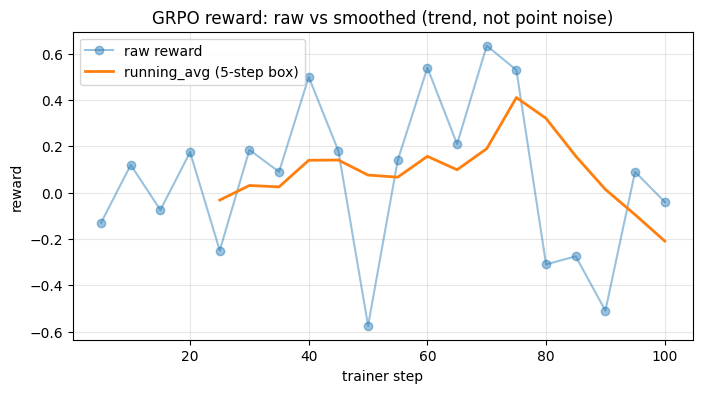

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Raw RL rewards are often noisy; smooth only in the plot (do not change the trainer).
rewards = np.asarray(grpo_rewards, dtype=float) if grpo_rewards else np.array([])

if len(rewards) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(grpo_reward_steps, grpo_rewards, marker='o', alpha=0.45, label='raw reward')
    if len(rewards) >= 5:
        running_avg = np.convolve(rewards, np.ones(5) / 5, mode='valid')
        steps_smooth = grpo_reward_steps[4 : 4 + len(running_avg)]
        plt.plot(steps_smooth, running_avg, linewidth=2, label='running_avg (5-step box)')
    else:
        print('(Need ≥5 reward points to plot 5-point running average; showing raw only.)')
    plt.title('GRPO reward: raw vs smoothed (trend, not point noise)')
    plt.xlabel('trainer step')
    plt.ylabel('reward')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No GRPO reward rows were logged yet. Run the GRPOTrainer cell above on Colab GPU.')

## 9b — Mic-drop: before vs after (same task set)

`before_report` used the **heuristic** baseline. After GRPO, we re-run **the same** `tasks` with the **trained** policy so judges see one line for success and one for hidden violations.

In [16]:
from environment.patch_env import CompliancePatchEnv
from unsloth import FastLanguageModel
from project.utils import clip_model_json_output
from project.agent import GENERATION_MAX_NEW_TOKENS
try:
    from project.compat_eos import json_action_eos_token_ids
except ImportError:
    try:
        from project.agent import json_action_eos_token_ids
    except ImportError:
        def json_action_eos_token_ids(tokenizer):
            _ids = []
            _e = getattr(tokenizer, 'eos_token_id', None)
            if _e is not None:
                _ids.append(int(_e))
            try:
                _r = tokenizer.encode('}', add_special_tokens=False)
                if _r:
                    _x = int(_r[-1])
                    if _x not in _ids:
                        _ids.append(_x)
            except Exception:
                pass
            return _ids
import torch, json

MAX_NEW_TOKENS = GENERATION_MAX_NEW_TOKENS
FastLanguageModel.for_inference(model)

def run_trained_agent(task, max_steps=8):
    env = CompliancePatchEnv()
    env.reset(task['task_id'], task['codebase'], task['violations'])
    prompt = build_prompt(task, PROMPT_CLOSING_LINES[0])
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt.split('---\n\n', 1)[-1]},
    ]
    for step in range(max_steps):
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors='pt').to(model.device)
        _e = json_action_eos_token_ids(tokenizer)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=0.1,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=_e if _e else tokenizer.eos_token_id,
            )
        completion = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        completion = clip_model_json_output(completion)
        actions = parse_json_actions(completion)
        action = actions[0] if actions else {'action_type': 'finalize_patch'}
        obs, r, done, info = env.step(action)
        messages.append({'role': 'assistant', 'content': completion})
        messages.append({'role': 'user', 'content': f'Result: {obs["action_result"][:150]}'})
        if done or action.get('action_type') == 'finalize_patch':
            return info.get('final_score', r)
    _, r, _, info = env.step({'action_type': 'finalize_patch'})
    return info.get('final_score', r)

print('=== Before vs After Training ===')
print(f'{"Task":<32} {"Before":>8} {"After":>8} {"Delta":>8}')
print('-' * 60)

after_scores = {}
for task in tasks:
    before = baseline_scores.get(task['task_id'], 0.0)
    after  = run_trained_agent(task)
    after_scores[task['task_id']] = after
    arrow = '↑' if after > before else ('↓' if after < before else '=')
    print(f'{task["task_id"]:<32} {before:>8.4f} {after:>8.4f} {arrow}{abs(after-before):>7.4f}')

avg_before = sum(baseline_scores.values()) / len(baseline_scores)
avg_after  = sum(after_scores.values()) / len(after_scores)
print('-' * 60)
print(f'{"AVERAGE":<32} {avg_before:>8.4f} {avg_after:>8.4f} {avg_after-avg_before:>+8.4f}')
print(f'\nImprovement: {(avg_after-avg_before):+.4f}')


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Before vs After Training ===
Task                               Before    After    Delta
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5

task1_single_file                  2.1000   2.5000 ↑ 0.4000


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

task5_fastapi                     -1.8000  -1.9000 ↓ 0.1000


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

task1b_connected_violations       -0.8000   1.6000 ↑ 2.4000


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

task2b_multifile_dependency       -0.8000   0.1000 ↑ 0.9000
------------------------------------------------------------
AVERAGE                            1.0143   2.7571  +1.7429

Improvement: +1.7429


## 10 — Step-by-step demo on a single task
Show the agent's decision trace on one task — useful for the demo video.

Each step shows the agent's decision and reward feedback, making the policy behavior easy to inspect.

In [ ]:
# Step-by-step demo trace (strong task + readable lines)
from environment.patch_env import CompliancePatchEnv
from project.utils import clip_model_json_output
from project.agent import GENERATION_MAX_NEW_TOKENS
try:
    from project.compat_eos import json_action_eos_token_ids
except ImportError:
    try:
        from project.agent import json_action_eos_token_ids
    except ImportError:
        def json_action_eos_token_ids(tokenizer):
            _ids = []
            _e = getattr(tokenizer, 'eos_token_id', None)
            if _e is not None:
                _ids.append(int(_e))
            try:
                _r = tokenizer.encode('}', add_special_tokens=False)
                if _r:
                    _x = int(_r[-1])
                    if _x not in _ids:
                        _ids.append(_x)
            except Exception:
                pass
            return _ids
from project.demo_trace import (
    DEMO_MAX_STEPS,
    format_demo_step_line,
    print_demo_task_header,
    print_final_demo_block,
    select_demo_task,
)
import torch, json

MAX_NEW_TOKENS = GENERATION_MAX_NEW_TOKENS
demo_task = select_demo_task(tasks)
print_demo_task_header(demo_task)
env = CompliancePatchEnv()
env.reset(
    demo_task["task_id"],
    demo_task["codebase"],
    demo_task["violations"],
    max_steps=min(20, int(demo_task.get("max_steps", 20))),
    file_reads_remaining=int(demo_task.get("file_reads_remaining", 5)),
)

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": build_prompt(demo_task, PROMPT_CLOSING_LINES[0]).split("---\n\n", 1)[-1]},
]

print("------------------------------------------------------------")
print("## EPISODE TRACE")
print("------------------------------------------------------------")
for step in range(DEMO_MAX_STEPS):
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    _e = json_action_eos_token_ids(tokenizer)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=_e if _e else tokenizer.eos_token_id,
        )
    completion = tokenizer.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
    completion = clip_model_json_output(completion)
    actions = parse_json_actions(completion)
    action = actions[0] if actions else {"action_type": "finalize_patch"}
    obs, r, done, info = env.step(action)
    print(format_demo_step_line(step + 1, action, r, obs))
    messages.append({"role": "assistant", "content": completion})
    messages.append({"role": "user", "content": f"Result: {str(obs.get('action_result', ''))[:150]}"})
    if done or action.get("action_type") == "finalize_patch":
        print_final_demo_block(info)
        break
else:
    print(f"  (Demo stopped: {DEMO_MAX_STEPS} step budget; no terminal state.)")


## 11 — Save the adapter + reports
Save the Colab-trained adapter and reports under `/content` so they can be downloaded after the run.

In [18]:
import shutil, json
from pathlib import Path

ADAPTER_DIR = '/content/grpo_adapter'
if Path(ADAPTER_DIR).exists():
    shutil.make_archive('/content/grpo_adapter', 'zip', root_dir=ADAPTER_DIR)
    print('Download: /content/grpo_adapter.zip')
else:
    print('No adapter found — did training complete?')

results = {
    'model': BASE_MODEL,
    'training_steps': MAX_STEPS,
    'baseline_avg': avg_baseline if 'avg_baseline' in dir() else None,
    'trained_avg': avg_after if 'avg_after' in dir() else None,
    'improvement': float(avg_after - avg_baseline) if ('avg_after' in dir() and 'avg_baseline' in dir()) else None,
    'per_task_baseline': baseline_scores if 'baseline_scores' in dir() else {},
    'per_task_trained': after_scores if 'after_scores' in dir() else {},
    'status': 'real_training_run',
}
with open('/content/training_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Download: /content/training_results.json')
if results['baseline_avg'] is not None:
    print(f'\nCopy into README:')
    print(f'  Baseline: {results["baseline_avg"]:.4f}')
    print(f'  Trained:  {results["trained_avg"]:.4f}')
    print(f'  Delta:    {results["improvement"]:+.4f}')


Download: /content/grpo_adapter.zip
Download: /content/training_results.json

Copy into README:
  Baseline: 1.0143
  Trained:  2.7571
  Delta:    +1.7429


In [19]:
import os, json, sys

# Verify notebook: syntax + no project.* + no truncated return + no wrong repo
root = os.environ.get('COMPLIANCEPATCHBENCH_NOTEBOOK', '/content/CompliancePatchBench/project')
nb_path = os.path.join(root, 'colab_training.ipynb') if not os.path.exists('colab_training.ipynb') else 'colab_training.ipynb'
if not os.path.exists(nb_path) and len(sys.argv) > 1:
    nb_path = sys.argv[1]
if not os.path.exists(nb_path):
    # Colab: clone default path
    alt = '/content/CompliancePatchBench/project/colab_training.ipynb'
    nb_path = alt if os.path.exists(alt) else nb_path

if not os.path.exists(nb_path):
    print('SKIP verify: colab_training.ipynb not found; run from project/ or set path')
else:
    with open(nb_path) as f:
        nb = json.load(f)
    errors = []
    def _scrub(src):
        s = src
        if s.startswith('%%capture'):
            s = s.split('\n', 1)[-1] if '\n' in s else ''
        out = []
        for line in s.splitlines(True):
            if line.lstrip().startswith('!'):
                out.append('# shell\n')
            elif line.lstrip().startswith(('%cd', '%pip', '%%')):
                out.append('# magic\n')
            else:
                out.append(line)
        return ''.join(out)
    for i, cell in enumerate(nb['cells']):
        if cell['cell_type'] != 'code': continue
        src = ''.join(cell['source'])
        src_clean = _scrub(src)
        try:
            compile(src_clean, f'cell_{i+1}', 'exec')
        except SyntaxError as e:
            errors.append(f'Cell {i+1}: {e}')
        if ('from ' + 'project.') in src or ('import ' + 'project.') in src:
            errors.append(f'Cell {i+1}: still has project.* import')
        if 'retur\n' in src and 'return' not in src:
            errors.append(f'Cell {i+1}: truncated return statement')
        if ('open' + 'env' + '_reg' + 'audit') in src:
            errors.append(f'Cell {i+1}: still has wrong repo URL')
    if errors:
        print('ISSUES FOUND:')
        for e in errors: print(f'  {e}')
    else:
        print('ALL CLEAR - notebook ready to run on Colab')


ALL CLEAR - notebook ready to run on Colab
